In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('train_data.csv')

C:\Users\Mahyar\AppData\Local\Temp\ipykernel_6596\767949749.py:3: DtypeWarning: Columns (0: vote) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('train_data.csv')


In [3]:
# نمایش نام ستون‌های دو فایل
print("ستون‌های train_data.csv:")
print(df.columns.tolist())

print("\nستون‌های overall_only.csv:")
overall_df = pd.read_csv("overall_only.csv", nrows=0)
print(overall_df.columns.tolist())

ستون‌های train_data.csv:
['overall', 'vote', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime']

ستون‌های overall_only.csv:
['overall']


In [4]:
import arabic_reshaper
from bidi.algorithm import get_display

def fix_farsi(text):
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

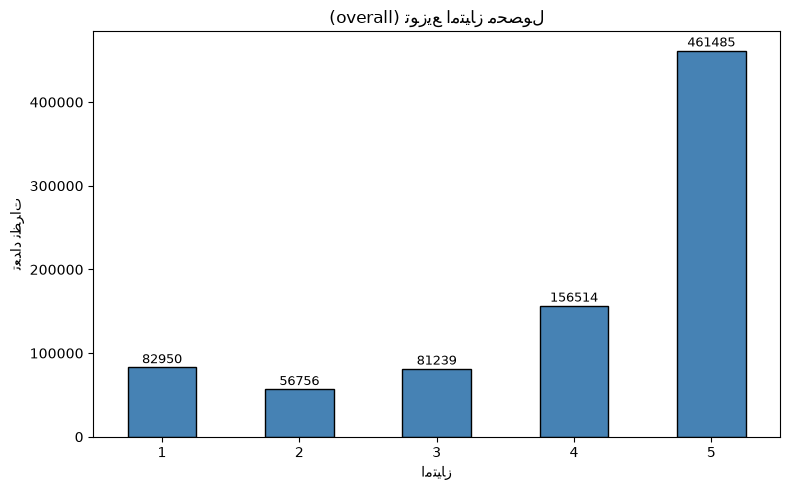

:ﺱﻼﮐ ﺮﻫ ﺪﺻﺭﺩ
overall
1     9.89
2     6.77
3     9.68
4    18.66
5    55.01
Name: count, dtype: float64


In [5]:
import matplotlib.pyplot as plt
counts = df['overall'].value_counts().sort_index()
percentages = (counts / len(df) * 100).round(2)

plt.figure(figsize=(8, 5))
counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title(fix_farsi('توزیع امتیاز محصول (overall)'))
plt.xlabel(fix_farsi('امتیاز'))
plt.ylabel(fix_farsi('تعداد نظرات'))
plt.xticks(rotation=0)
for i, v in enumerate(counts):
    plt.text(i, v + 5000, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(fix_farsi("درصد هر کلاس:"))
print(percentages)

In [6]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# محاسبه‌ی نسبت عدم‌توازن
imbalance_ratio = counts.max() / counts.min()
print(f"نسبت عدم‌توازن (بزرگترین کلاس به کوچکترین کلاس): {imbalance_ratio:.2f}")

# محاسبه‌ی وزن هر کلاس برای استفاده در مدل (بدون تغییر خود df)
classes = np.sort(df['overall'].unique())
weights = compute_class_weight(class_weight='balanced', classes=classes, y=df['overall'])
class_weight_dict = dict(zip(classes, weights))

print("\nوزن هر کلاس (برای استفاده در مدل، جهت جبران عدم‌توازن):")
for cls, w in class_weight_dict.items():
    print(f"  کلاس {cls}: وزن = {w:.3f}")

نسبت عدم‌توازن (بزرگترین کلاس به کوچکترین کلاس): 8.13

وزن هر کلاس (برای استفاده در مدل، جهت جبران عدم‌توازن):
  کلاس 1: وزن = 2.023
  کلاس 2: وزن = 2.956
  کلاس 3: وزن = 2.065
  کلاس 4: وزن = 1.072
  کلاس 5: وزن = 0.364


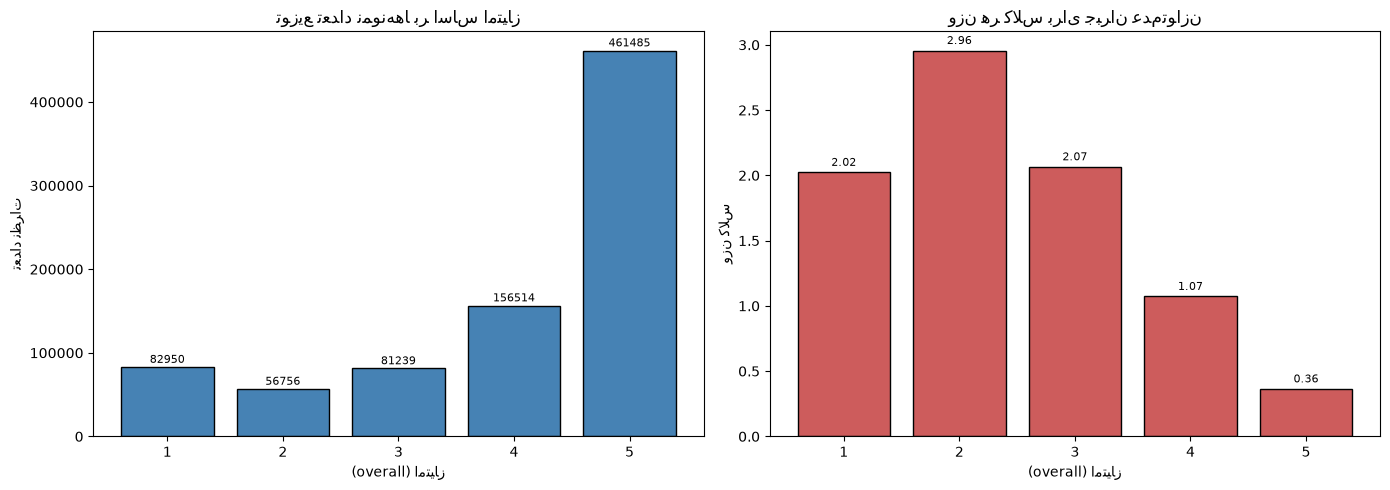

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# نمودار اول: توزیع تعداد نمونه‌ها
axes[0].bar(counts.index, counts.values, color='steelblue', edgecolor='black')
axes[0].set_title(fix_farsi('توزیع تعداد نمونه‌ها بر اساس امتیاز'))
axes[0].set_xlabel(fix_farsi('امتیاز (overall)'))
axes[0].set_ylabel(fix_farsi('تعداد نظرات'))
axes[0].set_xticks(counts.index)
for i, v in zip(counts.index, counts.values):
    axes[0].text(i, v + 5000, str(v), ha='center', fontsize=8)

# نمودار دوم: وزن هر کلاس
classes_list = list(class_weight_dict.keys())
weights_list = list(class_weight_dict.values())
axes[1].bar(classes_list, weights_list, color='indianred', edgecolor='black')
axes[1].set_title(fix_farsi('وزن هر کلاس برای جبران عدم‌توازن'))
axes[1].set_xlabel(fix_farsi('امتیاز (overall)'))
axes[1].set_ylabel(fix_farsi('وزن کلاس'))
axes[1].set_xticks(classes_list)
for i, w in enumerate(weights_list):
    axes[1].text(classes_list[i], w + 0.05, f"{w:.2f}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()